In [2]:
pip install tensorflow==2.10

In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


In [2]:
import tensorflow as tf

# نمایش نسخه‌ی TensorFlow
print("TensorFlow version:", tf.__version__)

# چک کردن GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ GPU Available:", gpus)
else:
    print("❌ No GPU detected.")


TensorFlow version: 2.10.0
✅ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


✅ GPU mode activated


c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.078s...
[t-SNE] Computed neighbors for 50000 samples in 143.268s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for s

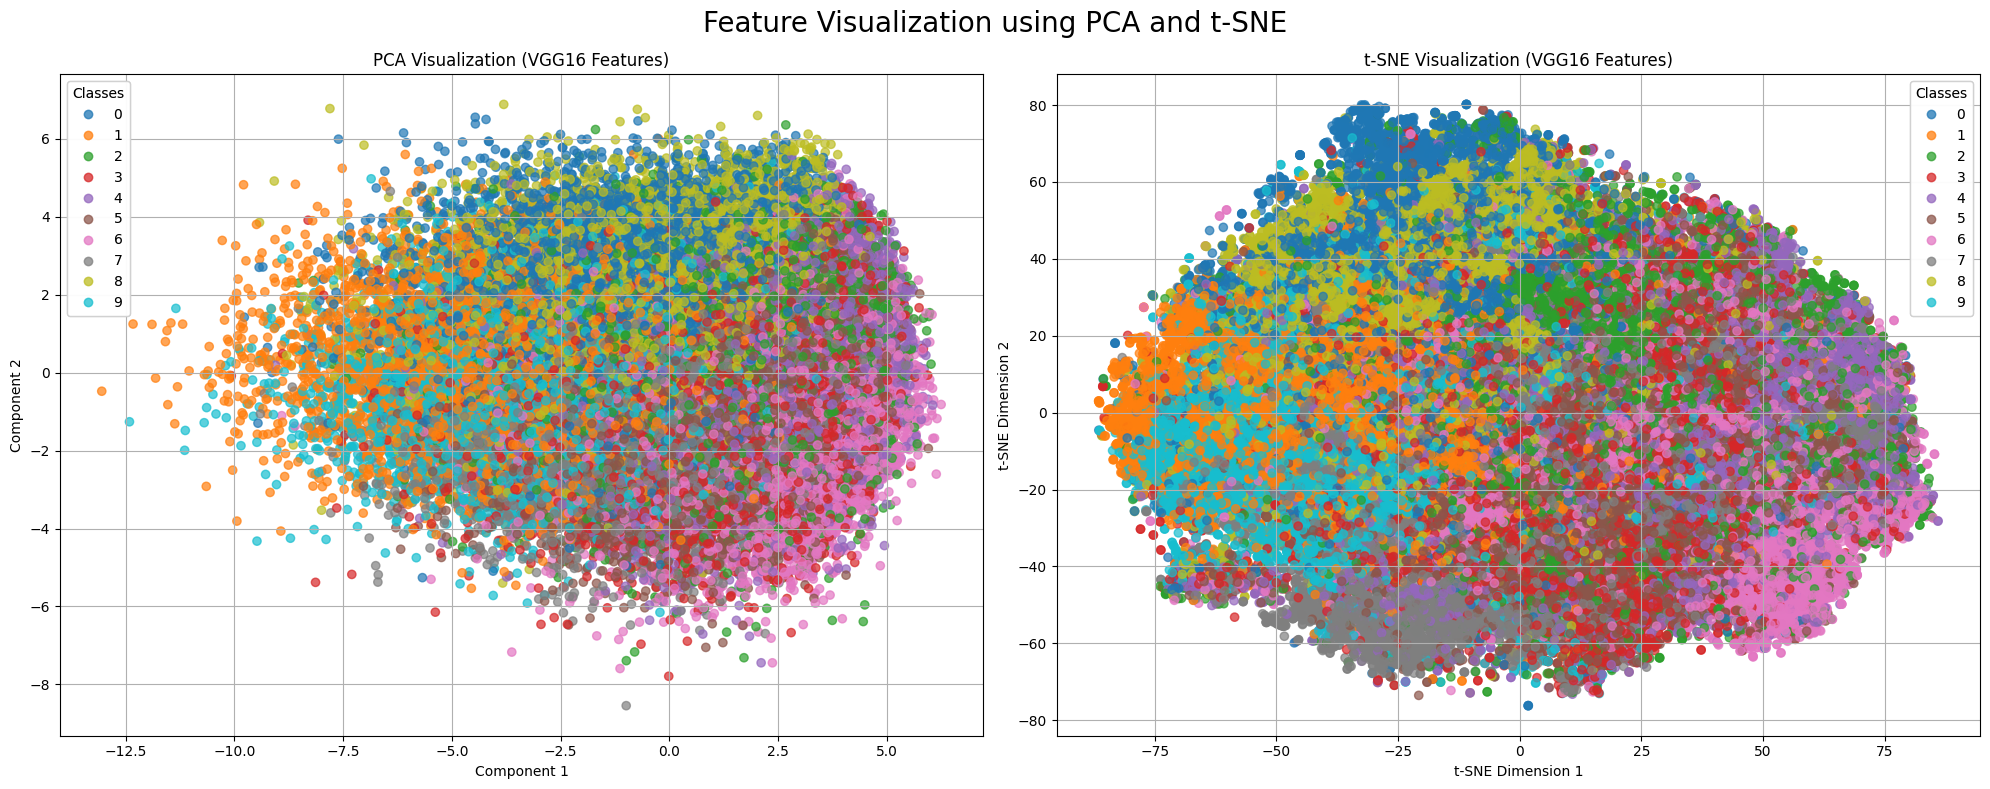

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model

# Force TensorFlow to use GPU if available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU mode activated")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU found, running on CPU.")

# Load CIFAR-10 dataset
(x_train, y_train), (_, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0

# Load pretrained VGG16 model
base_model = VGG16(weights='imagenet', include_top=True)

# Create a feature extractor model
feature_extractor = Model(inputs=base_model.input, outputs=base_model.get_layer('fc1').output)

# Parameters
batch_size = 16  # You can increase if your GPU allows
num_batches = int(np.ceil(len(x_train) / batch_size))

# Initialize empty list for features
features_list = []

# Process batches
for batch_idx in range(num_batches):
    start = batch_idx * batch_size
    end = min((batch_idx + 1) * batch_size, len(x_train))
    
    x_batch = x_train[start:end]
    
    # Resize the batch
    x_batch_resized = tf.image.resize(x_batch, (224, 224))
    
    # Extract features
    features_batch = feature_extractor.predict(x_batch_resized, verbose=0)
    
    features_list.append(features_batch)

# Concatenate all features
features = np.vstack(features_list)

# Flatten labels
y_train = y_train.flatten()

# =========================
# Dimensionality Reduction
# =========================

# 1. PCA
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features)

# 2. t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
features_tsne = tsne.fit_transform(features)

# =========================
# Plotting
# =========================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot PCA
scatter1 = axes[0].scatter(features_pca[:, 0], features_pca[:, 1], c=y_train, cmap='tab10', alpha=0.7)
legend1 = axes[0].legend(*scatter1.legend_elements(), title="Classes")
axes[0].add_artist(legend1)
axes[0].set_title('PCA Visualization (VGG16 Features)')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
axes[0].grid(True)

# Plot t-SNE
scatter2 = axes[1].scatter(features_tsne[:, 0], features_tsne[:, 1], c=y_train, cmap='tab10', alpha=0.7)
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Classes")
axes[1].add_artist(legend2)
axes[1].set_title('t-SNE Visualization (VGG16 Features)')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(True)

plt.suptitle('Feature Visualization using PCA and t-SNE', fontsize=20)
plt.tight_layout()
plt.show()


In [5]:
tf.keras.backend.clear_session()

In [1]:
import psutil
print("Total RAM:", psutil.virtual_memory().total / (1024 ** 3), "GB")
print("Available RAM:", psutil.virtual_memory().available / (1024 ** 3), "GB")


Total RAM: 15.845481872558594 GB
Available RAM: 10.612548828125 GB


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=False)

# 2. Load pretrained VGG16 model
vgg16 = torchvision.models.vgg16(pretrained=True)
vgg16.eval()

# 3. Remove the last layer to extract features
feature_extractor = nn.Sequential(*list(vgg16.children())[:-1])  # Remove classifier

# 4. Extract features
all_features = []
all_labels = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor = feature_extractor.to(device)

with torch.no_grad():
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        features = feature_extractor(inputs)
        features = features.view(features.size(0), -1)  # Flatten
        all_features.append(features.cpu())
        all_labels.append(labels)

all_features = torch.cat(all_features).numpy()
all_labels = torch.cat(all_labels).numpy()

# 5. Reduce dimensions

# --- Using PCA
pca = PCA(n_components=2)
features_pca = pca.fit_transform(all_features)

# --- Using t-SNE (optional)
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# features_pca = tsne.fit_transform(all_features)

# 6. Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Feature Visualization with PCA (VGG16 Features)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()


c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


KeyboardInterrupt: 

In [1]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# بارگذاری مدل VGG16 بدون لایه‌های Fully Connected
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False)

# بارگذاری مجموعه داده CIFAR-10
(x_train, y_train), (_, _) = tf.keras.datasets.cifar10.load_data()

# تابع پردازش دسته‌ای برای تغییر اندازه تصاویر
def batch_resize(images, batch_size=100):
    resized_images = []
    for i in range(0, len(images), batch_size):
        batch = tf.image.resize(images[i:i+batch_size], (128, 128))
        resized_images.append(batch.numpy())  # تبدیل به آرایه NumPy برای کاهش مصرف حافظه
    return np.vstack(resized_images)

# تغییر اندازه داده‌ها با پردازش دسته‌ای
x_train_resized = batch_resize(x_train)

# پیش‌پردازش داده‌ها برای هماهنگی با VGG
x_train_resized = tf.keras.applications.vgg16.preprocess_input(x_train_resized)

# تابع پردازش دسته‌ای برای استخراج ویژگی‌ها
def batch_extract_features(images, batch_size=100):
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch_features = base_model.predict(batch)
        features.append(batch_features.reshape(batch_features.shape[0], -1))  # تبدیل به آرایه یک‌بعدی
    return np.vstack(features)

# استخراج ویژگی‌ها به‌صورت دسته‌ای
features = batch_extract_features(x_train_resized)

# کاهش بعد با PCA
pca = PCA(n_components=50)
features_pca = pca.fit_transform(features)

# کاهش بیشتر ابعاد با t-SNE و نمایش داده‌ها
tsne = TSNE(n_components=2)
features_tsne = tsne.fit_transform(features_pca)

plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=y_train.flatten(), cmap='tab10')
plt.title("نمایش ویژگی‌های استخراج‌شده توسط VGG")
plt.show()


MemoryError: Unable to allocate 146. MiB for an array with shape (50000, 3, 32, 32) and data type uint8

In [1]:
import psutil
print("Total RAM:", psutil.virtual_memory().total / (1024 ** 3), "GB")
print("Available RAM:", psutil.virtual_memory().available / (1024 ** 3), "GB")


Total RAM: 15.845481872558594 GB
Available RAM: 10.282356262207031 GB


4/4 [==============================] - 0s 77ms/step


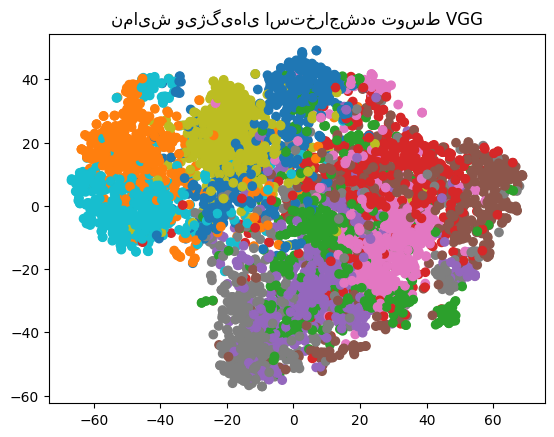

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# بارگذاری مدل VGG16 بدون لایه‌های Fully Connected
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False)

# بارگذاری فقط 5000 داده از CIFAR-10
(x_train, y_train), (_, _) = tf.keras.datasets.cifar10.load_data()
x_train_subset = x_train[:5000]  # فقط 5000 تصویر را پردازش کن
y_train_subset = y_train[:5000]

# تابع پردازش دسته‌ای برای تغییر اندازه تصاویر
def batch_resize(images, batch_size=100):
    resized_images = []
    for i in range(0, len(images), batch_size):
        batch = tf.image.resize(images[i:i+batch_size], (128, 128))  # تغییر اندازه به 128x128
        resized_images.append(batch.numpy())  # تبدیل به آرایه NumPy
    return np.vstack(resized_images)

# تغییر اندازه داده‌ها با پردازش دسته‌ای
x_train_resized = batch_resize(x_train_subset)

# پیش‌پردازش داده‌ها برای هماهنگی با VGG
x_train_resized = tf.keras.applications.vgg16.preprocess_input(x_train_resized)

# تابع پردازش دسته‌ای برای استخراج ویژگی‌ها
def batch_extract_features(images, batch_size=100):
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch_features = base_model.predict(batch)
        features.append(batch_features.reshape(batch_features.shape[0], -1))  # تبدیل به آرایه یک‌بعدی
    return np.vstack(features)

# استخراج ویژگی‌ها به‌صورت دسته‌ای
features = batch_extract_features(x_train_resized)

# کاهش بعد با PCA
pca = PCA(n_components=50)
features_pca = pca.fit_transform(features)

# کاهش بیشتر ابعاد با t-SNE و نمایش داده‌ها
tsne = TSNE(n_components=2)
features_tsne = tsne.fit_transform(features_pca)

plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=y_train_subset.flatten(), cmap='tab10')
plt.title("نمایش ویژگی‌های استخراج‌شده توسط VGG")
plt.show()


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=False)

# 2. Load pretrained VGG16 model
vgg16 = torchvision.models.vgg16(pretrained=True)
vgg16.eval()

# 3. Remove the last layer to extract features
feature_extractor = nn.Sequential(*list(vgg16.children())[:-1])  # Remove classifier

# 4. Extract features
all_features = []
all_labels = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor = feature_extractor.to(device)

with torch.no_grad():
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        features = feature_extractor(inputs)
        features = features.view(features.size(0), -1)  # Flatten
        all_features.append(features.cpu())
        all_labels.append(labels)

all_features = torch.cat(all_features).numpy()
all_labels = torch.cat(all_labels).numpy()

# 5. Reduce dimensions

# --- Using PCA
pca = PCA(n_components=2)
features_pca = pca.fit_transform(all_features)

# --- Using t-SNE (optional)
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# features_pca = tsne.fit_transform(all_features)

# 6. Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Feature Visualization with PCA (VGG16 Features)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()


c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


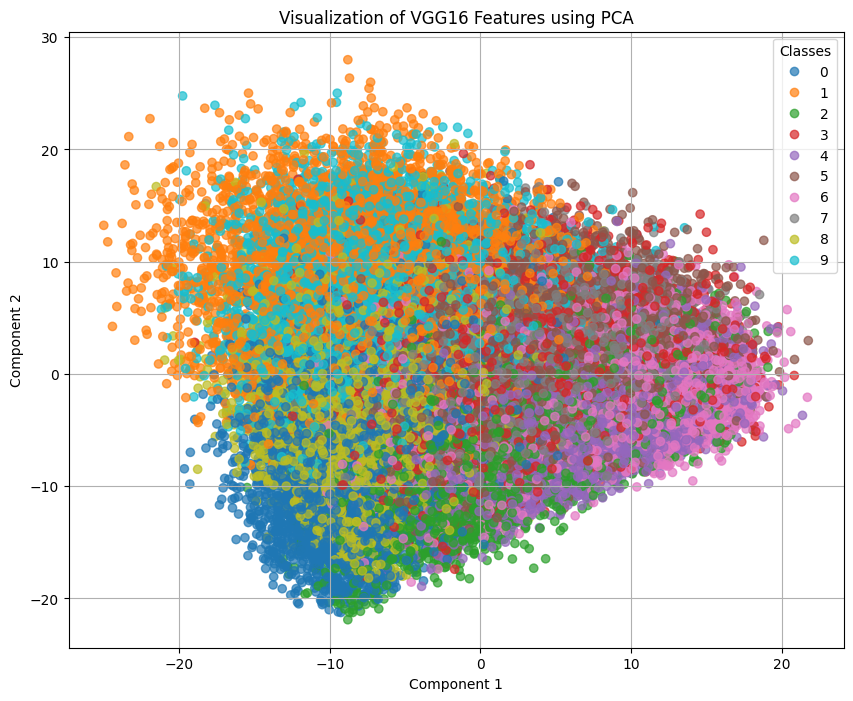

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. تنظیمات دستگاه (GPU در صورت موجود بودن)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. بارگذاری دیتاست CIFAR-10
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=False)

# 3. بارگذاری مدل VGG16 و انتقال به GPU
vgg16 = torchvision.models.vgg16(pretrained=True).to(device)
vgg16.eval()

# 4. حذف لایه آخر برای استخراج ویژگی‌ها
feature_extractor = nn.Sequential(*list(vgg16.features)).to(device)

# 5. استخراج ویژگی‌ها با پردازش کامل در GPU
all_features = []
all_labels = []

with torch.no_grad():
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        features = feature_extractor(inputs)
        features = features.view(features.size(0), -1)  # مسطح کردن ویژگی‌ها
        all_features.append(features)
        all_labels.append(labels)

all_features = torch.cat(all_features).cpu().numpy()
all_labels = torch.cat(all_labels).cpu().numpy()

# 6. کاهش ابعاد با استفاده از PCA
pca = PCA(n_components=2)
features_pca = pca.fit_transform(all_features)

# 7. رسم نمودار
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Visualization of VGG16 Features using PCA')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

# تنظیمات GPU برای بهبود عملکرد
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

# بارگیری داده‌های CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# انتخاب زیرمجموعه‌ای از داده‌ها برای سرعت بخشیدن به پردازش
num_samples = 2000  # تعداد نمونه‌ها را می‌توانید تغییر دهید
x_train = x_train[:num_samples]
y_train = y_train[:num_samples].flatten()

# نام کلاس‌های CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# پیش‌پردازش تصاویر برای مدل VGG
def preprocess_images(images):
    # تغییر اندازه تصاویر به 224x224 که اندازه ورودی VGG است
    images_resized = tf.image.resize(images, [224, 224])
    # پیش‌پردازش مخصوص VGG
    return preprocess_input(images_resized)

x_train_preprocessed = preprocess_images(x_train)

# بارگیری مدل VGG16 از پیش آموزش دیده
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# ایجاد مدل جدید که خروجی لایه قبل از fully connected را می‌دهد
feature_extractor = Model(inputs=base_model.input, 
                         outputs=base_model.get_layer('block5_pool').output)

# استخراج ویژگی‌ها
features = feature_extractor.predict(x_train_preprocessed, batch_size=32)

# تغییر شکل ویژگی‌ها به بردار یک بعدی
features_flat = features.reshape(features.shape[0], -1)

# کاهش بعد با t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_tsne = tsne.fit_transform(features_flat)

# نمایش نتایج
plt.figure(figsize=(12, 10))
scatter = plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=y_train, 
                     cmap='tab10', alpha=0.6)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, 
           title="Classes")
plt.title('t-SNE Visualization of VGG16 Features for CIFAR-10')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Class')
plt.show()

ResourceExhaustedError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[2000,224,224,3] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:StridedSlice] name: strided_slice/

در حال بارگیری مدل VGG16...
در حال استخراج ویژگی‌ها به صورت دسته‌ای...
پردازش دسته 1/63
پردازش دسته 11/63
پردازش دسته 21/63
پردازش دسته 31/63
پردازش دسته 41/63
پردازش دسته 51/63
پردازش دسته 61/63
در حال اجرای t-SNE...


c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


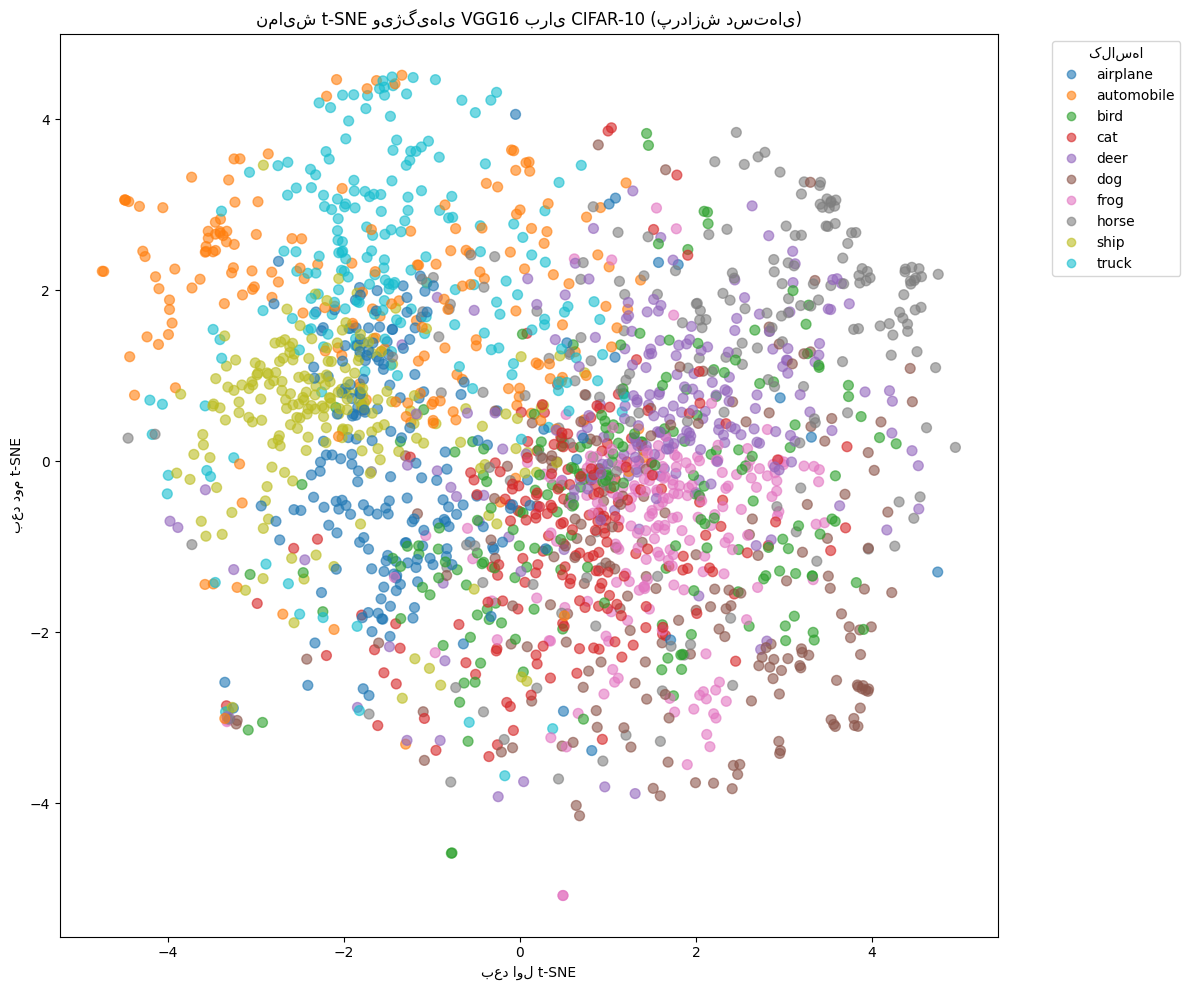

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# تنظیمات GPU برای جلوگیری از مصرف تمام حافظه
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

# بارگیری داده‌های CIFAR-10
(x_train, y_train), _ = cifar10.load_data()

# نام کلاس‌های CIFAR-10 برای نمایش در نمودار
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# تعداد نمونه‌ها و اندازه دسته
num_samples = 2000  # می‌توانید این مقدار را تغییر دهید
batch_size = 32    # با توجه به حافظه GPU می‌توانید کاهش دهید

x_train = x_train[:num_samples]
y_train = y_train[:num_samples].flatten()

## توابع پردازش دسته‌ای

def preprocess_batch(images):
    """پیش‌پردازش دسته‌ای تصاویر برای مدل VGG"""
    # تغییر اندازه به 224x224 که اندازه ورودی VGG است
    images_resized = tf.image.resize(images, [224, 224])
    # پیش‌پردازش مخصوص VGG (تبدیل RGB به BGR و کم کردن میانگین)
    return preprocess_input(images_resized)

def extract_features_batch(model, images, batch_size=32):
    """استخراج ویژگی‌ها به صورت دسته‌ای"""
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        # پیش‌پردازش دسته‌ای
        processed_batch = preprocess_batch(batch)
        # استخراج ویژگی‌ها
        features_batch = model.predict(processed_batch, verbose=0)
        features.append(features_batch)
        # نمایش پیشرفت
        if (i // batch_size) % 10 == 0:
            print(f"پردازش دسته {i//batch_size + 1}/{(len(images)-1)//batch_size + 1}")
    
    return np.vstack(features)

## بارگیری مدل VGG16
print("در حال بارگیری مدل VGG16...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# ایجاد مدل برای استخراج ویژگی‌ها از لایه block5_pool
feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer('block5_pool').output
)

## استخراج ویژگی‌ها به صورت دسته‌ای
print("در حال استخراج ویژگی‌ها به صورت دسته‌ای...")
features = extract_features_batch(feature_extractor, x_train, batch_size)

# تغییر شکل ویژگی‌ها به بردار یک بعدی
features_flat = features.reshape(features.shape[0], -1)

## کاهش بعد با t-SNE
print("در حال اجرای t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_tsne = tsne.fit_transform(features_flat)

## نمایش نتایج
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    features_tsne[:, 0], 
    features_tsne[:, 1], 
    c=y_train, 
    cmap='tab10',
    alpha=0.6,
    s=50  # اندازه نقاط
)

# ایجاد لیجن با نام کلاس‌ها
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="کلاس‌ها",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title('نمایش t-SNE ویژگی‌های VGG16 برای CIFAR-10 (پردازش دسته‌ای)')
plt.xlabel('بعد اول t-SNE')
plt.ylabel('بعد دوم t-SNE')
plt.tight_layout()
plt.show()

Loading VGG16 model...
Extracting features in batches...
Processed batch 10/157
Processed batch 20/157
Processed batch 30/157
Processed batch 40/157
Processed batch 50/157
Processed batch 60/157
Processed batch 70/157
Processed batch 80/157
Processed batch 90/157
Processed batch 100/157
Processed batch 110/157
Processed batch 120/157
Processed batch 130/157
Processed batch 140/157
Processed batch 150/157
Processed batch 157/157
Running t-SNE dimensionality reduction...


c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


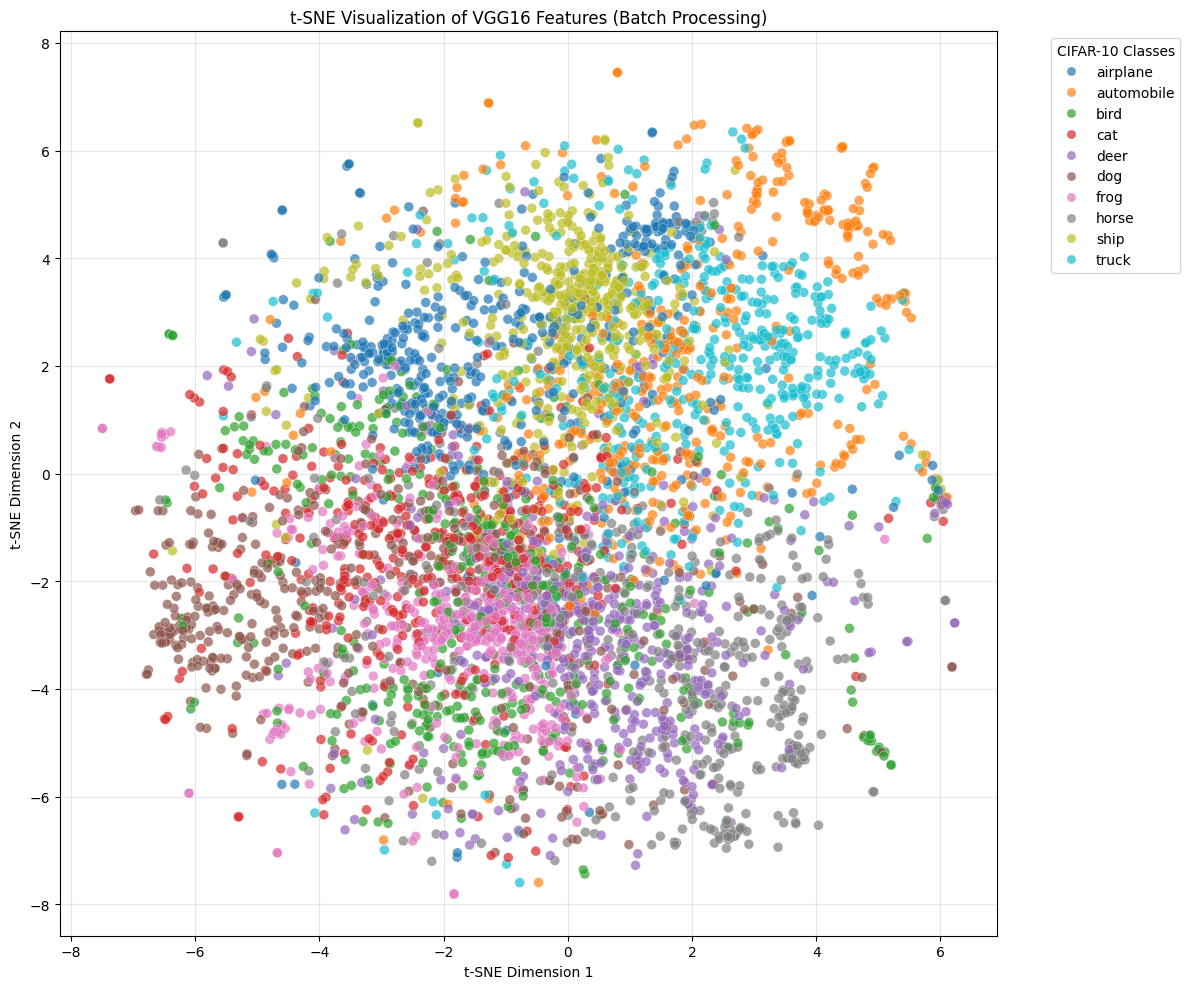

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

## 1. تنظیمات اولیه و GPU Configuration
# فعال کردن رشد پویای حافظه برای جلوگیری از خطای OOM
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

## 2. بارگیری و آماده‌سازی داده‌ها
# بارگیری مجموعه داده CIFAR-10
(x_train, y_train), _ = cifar10.load_data()

# لیست نام کلاس‌ها برای نمایش در نمودار
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# پارامترهای نمونه‌گیری
num_samples = 5000  # تعداد نمونه‌های مورد استفاده
batch_size = 32     # اندازه هر دسته برای پردازش

# انتخاب زیرمجموعه داده‌ها
x_train = x_train[:num_samples]
y_train = y_train[:num_samples].flatten()

## 3. توابع کمکی برای پردازش دسته‌ای
def preprocess_batch(images):
    """
    پیش‌پردازش تصاویر برای مدل VGG
    - تغییر اندازه به 224x224 پیکسل
    - تبدیل مقادیر پیکسل‌ها به فرمت مورد نیاز VGG
    """
    images_resized = tf.image.resize(images, [224, 224])
    return preprocess_input(images_resized)

def extract_features_batch(model, images, batch_size=32):
    """
    استخراج ویژگی‌ها به صورت دسته‌ای
    - پردازش تصاویر در دسته‌های کوچک
    - جلوگیری از مصرف بیش از حد حافظه GPU
    """
    features = []
    total_batches = (len(images) - 1) // batch_size + 1
    
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        processed_batch = preprocess_batch(batch)
        features_batch = model.predict(processed_batch, verbose=0)
        features.append(features_batch)
        
        # نمایش پیشرفت پردازش
        current_batch = i // batch_size + 1
        if current_batch % 10 == 0 or current_batch == total_batches:
            print(f"Processed batch {current_batch}/{total_batches}")
    
    return np.vstack(features)

## 4. بارگیری مدل VGG16
print("Loading VGG16 model...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# ایجاد مدل برای استخراج ویژگی‌ها از لایه میانی
feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer('block5_pool').output
)

## 5. استخراج ویژگی‌ها
print("Extracting features in batches...")
features = extract_features_batch(feature_extractor, x_train, batch_size)

# تبدیل ویژگی‌ها به بردارهای یک بعدی
features_flat = features.reshape(features.shape[0], -1)

## 6. کاهش ابعاد با t-SNE
print("Running t-SNE dimensionality reduction...")
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000,
    learning_rate=200
)
features_tsne = tsne.fit_transform(features_flat)

## 7. نمایش نتایج
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    features_tsne[:, 0],
    features_tsne[:, 1],
    c=y_train,
    cmap='tab10',
    alpha=0.7,
    s=50,
    edgecolor='w',
    linewidth=0.3
)

# اضافه کردن legend و عنوان‌ها
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="CIFAR-10 Classes",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title('t-SNE Visualization of VGG16 Features (Batch Processing)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()